# ЛАБОРАТОРНАЯ РАБОТА №2
### Тема: «Интерполяционный кубический сплайн»

**Вариант №9**


Выполнил:
Студент группы 4\
Минковский Виталий Викторович

## Постановка задачи

Требуется написать программу, которая строит на отрезке $[a, b]$ для данной функции $f(x)$ интерполяционный кубический сплайн $S_3(x)$. Узлы интерполяции выбираются равноотстоящими: 

$x_i = a + i \cdot h$, где $i = 0, \dots, N$, а $h = \frac{b-a}{N}$

Здесь $N$ — число разбиений отрезка. Система линейных алгебраических уравнений (СЛАУ) с трехдиагональной матрицей для нахождения параметров сплайна должна решаться методом прогонки.

**Данные варианта 9:**
1. Функция $f_1(x) = \sin(x)$
2. Функция $f_2(x) = \sqrt{|x| + 4}$
3. Отрезок: $[a, b] = [-3, 3]$
4. Граничные условия: $S_3'(a) = f'(a), \quad S_3''(b) = f''(b)$

С помощью программы необходимо провести вычислительный эксперимент:
1. Построить совмещенный график функции и сплайна при $N=15$, вычислить максимальную погрешность на плотной сетке (501 точка).
2. Построить график сходимости сплайна (зависимость нормы погрешности от $N$) в логарифмическом масштабе по обеим осям для $N$ от 5 до 100 с шагом 5.
3. Сделать выводы о сходимости в зависимости от гладкости функции.

## Краткие теоретические сведения

### Алгоритм построения интерполяционного кубического сплайна
Интерполяционный кубический сплайн $S_3(x)$ на каждом отрезке $[x_{i-1}, x_i]$ (где $i = 1, \dots, N$) ищется в виде полинома третьей степени:

$S_{3,i}(x) = \alpha_i + \beta_i(x - x_i) + \frac{\gamma_i}{2}(x - x_i)^2 + \frac{\delta_i}{6}(x - x_i)^3$

Для нахождения коэффициентов используется условие непрерывности функции и её первой и второй производных во внутренних узлах. Обозначим $\gamma_i = S_3''(x_i)$ — моменты сплайна. Из условий гладкой склейки выводится СЛАУ относительно моментов $\gamma_i$. Для равномерной сетки с шагом $h$ внутренние уравнения системы имеют вид:

$\gamma_{i-1} + 4\gamma_i + \gamma_{i+1} = \frac{6}{h^2}(y_{i-1} - 2y_i + y_{i+1}), \quad i = 1, \dots, N-1$

Коэффициенты сплайна выражаются через моменты $\gamma_i$ и заданные значения $y_i = f(x_i)$ следующими формулами:

$\alpha_i = y_i$

$\delta_i = \frac{\gamma_i - \gamma_{i-1}}{h}$

$\beta_i = \frac{y_i - y_{i-1}}{h} + \frac{2\gamma_i + \gamma_{i-1}}{6}h$

### СЛАУ для заданных граничных условий
* На левом конце задана первая производная: $S_3'(x_0) = y'_0$
* На правом конце задана вторая производная: $S_3''(x_N) = y''_N$

По определению моментов, условие на правом конце сразу даёт значение последнего момента:

$\gamma_N = y''_N$

Условие на левом конце определяет первое уравнение системы:

$2\gamma_0 + \gamma_1 = \frac{6}{h}\left(\frac{y_1 - y_0}{h} - y'_0\right)$

Таким образом, неизвестными остаются моменты $\gamma_0, \gamma_1, \dots, \gamma_{N-1}$. Итоговая СЛАУ порядка $N \times N$ принимает следующий трехдиагональный вид:

Уравнение 1 (для $i=0$): 
$2\gamma_0 + \gamma_1 = \frac{6}{h^2}(y_1 - y_0) - \frac{6}{h}y'_0$

Внутренние уравнения (для $i = 1, \dots, N-2$): 
$\gamma_{i-1} + 4\gamma_i + \gamma_{i+1} = \frac{6}{h^2}(y_{i-1} - 2y_i + y_{i+1})$

Уравнение $N$ (для $i=N-1$): 
$\gamma_{N-2} + 4\gamma_{N-1} = \frac{6}{h^2}(y_{N-2} - 2y_{N-1} + y_N) - \gamma_N$


### Алгоритм метода прогонки
Полученная система $A\gamma = d$ имеет трехдиагональную матрицу с диагональным преобладанием, что гарантирует устойчивость метода прогонки. 
Пусть уравнения системы имеют вид $c_i \gamma_{i-1} + a_i \gamma_i + b_i \gamma_{i+1} = d_i$.
Алгоритм состоит из двух этапов:

1. **Прямой ход (вычисление прогоночных коэффициентов):**

$P_0 = -\frac{b_0}{a_0}, \quad Q_0 = \frac{d_0}{a_0}$

$P_i = -\frac{b_i}{a_i + c_i P_{i-1}}, \quad Q_i = \frac{d_i - c_i Q_{i-1}}{a_i + c_i P_{i-1}}, \quad i = 1, \dots, N-1$

2. **Обратный ход (вычисление корней):**

$\gamma_{N-1} = Q_{N-1}$

$\gamma_i = P_i \gamma_{i+1} + Q_i, \quad i = N-2, \dots, 0$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f1(x):
    """Первая целевая функция: sin(x)"""
    return np.sin(x)

def df1(x):
    """Первая производная первой функции"""
    return np.cos(x)

def d2f1(x):
    """Вторая производная первой функции"""
    return -np.sin(x)

def f2(x):
    """Вторая целевая функция: sqrt(|x| + 4)"""
    return np.sqrt(np.abs(x) + 4)

def df2(x):
    """
    Первая производная второй функции.
    Модуль раскрывается по-разному для положительных и отрицательных x.
    """
    sign = np.where(x >= 0, 1, -1)
    return sign / (2 * np.sqrt(np.abs(x) + 4))

def d2f2(x):
    """
    Вторая производная второй функции.
    """
    return -1 / (4 * (np.abs(x) + 4)**1.5)

In [2]:
def thomas_algorithm(a, b, c, d):
    """
    Метод прогонки для решения трехдиагональной СЛАУ.
    Обозначения: a - главная диагональ, b - верхняя, c - нижняя, d - вектор правой части.
    """
    n = len(d)
    p = np.zeros(n)
    q = np.zeros(n)
    x = np.zeros(n)

    p[0] = -b[0] / a[0]
    q[0] = d[0] / a[0]

    for i in range(1, n):
        denominator = a[i] + c[i] * p[i - 1]
        
        if i < n - 1:
            p[i] = -b[i] / denominator
            
        q[i] = (d[i] - c[i] * q[i - 1]) / denominator

    x[n - 1] = q[n - 1]
    
    for i in range(n - 2, -1, -1):
        x[i] = p[i] * x[i + 1] + q[i]
        
    return x


class CubicSpline:
    """
    Класс, инкапсулирующий логику построения интерполяционного кубического сплайна.
    Реализует смешанные граничные условия варианта 9: S'(a) = y'_0, S''(b) = y''_N.
    """
    def __init__(self, x_nodes, y_nodes, dy_start, d2y_end):
        self.x = x_nodes
        self.y = y_nodes
        self.n = len(x_nodes) - 1
        self.h = (self.x[-1] - self.x[0]) / self.n
        
        self.gamma = np.zeros(self.n + 1)
        self.alpha = np.zeros(self.n + 1)
        self.beta = np.zeros(self.n + 1)
        self.delta = np.zeros(self.n + 1)
        
        self._build_spline(dy_start, d2y_end)

    def _build_spline(self, dy_start, d2y_end):
        """Решение СЛАУ и вычисление коэффициентов сплайна."""
        diag_main = np.zeros(self.n)
        diag_up = np.zeros(self.n)
        diag_down = np.zeros(self.n)
        rhs = np.zeros(self.n)

        self.gamma[self.n] = d2y_end

        diag_main[0] = 2.0
        diag_up[0] = 1.0
        rhs[0] = (6.0 / self.h**2) * (self.y[1] - self.y[0]) - (6.0 / self.h) * dy_start

        for i in range(1, self.n - 1):
            diag_down[i] = 1.0
            diag_main[i] = 4.0
            diag_up[i] = 1.0
            rhs[i] = (6.0 / self.h**2) * (self.y[i - 1] - 2 * self.y[i] + self.y[i + 1])

        if self.n > 1:
            diag_down[self.n - 1] = 1.0
            diag_main[self.n - 1] = 4.0
            rhs[self.n - 1] = (6.0 / self.h**2) * (self.y[self.n - 2] - 2 * self.y[self.n - 1] + self.y[self.n]) - self.gamma[self.n]

        calculated_gammas = thomas_algorithm(diag_main, diag_up, diag_down, rhs)
        self.gamma[:self.n] = calculated_gammas

        for i in range(1, self.n + 1):
            self.alpha[i] = self.y[i]
            self.delta[i] = (self.gamma[i] - self.gamma[i - 1]) / self.h
            self.beta[i] = (self.y[i] - self.y[i - 1]) / self.h + (2 * self.gamma[i] + self.gamma[i - 1]) * self.h / 6.0

    def evaluate(self, x_eval):
        """
        Вычисление значения сплайна в заданных точках.
        Поиск интервала осуществляется с помощью встроенных средств библиотеки NumPy.
        """
        x_eval = np.atleast_1d(x_eval)
        result = np.zeros_like(x_eval)

        indices = np.searchsorted(self.x, x_eval)
        indices = np.clip(indices, 1, self.n)

        for j, x_val in enumerate(x_eval):
            i = indices[j]
            dx = x_val - self.x[i]
            
            val = self.alpha[i] + \
                  self.beta[i] * dx + \
                  (self.gamma[i] / 2.0) * dx**2 + \
                  (self.delta[i] / 6.0) * dx**3
            result[j] = val
            
        return result if len(result) > 1 else result[0]

## Вычислительный эксперимент
Ниже представлены графики интерполяции для заданных функций, а также анализ сходимости (убывания ошибки при измельчении сетки).

--- ЭКСПЕРИМЕНТ 1: f1(x) = sin(x) ---


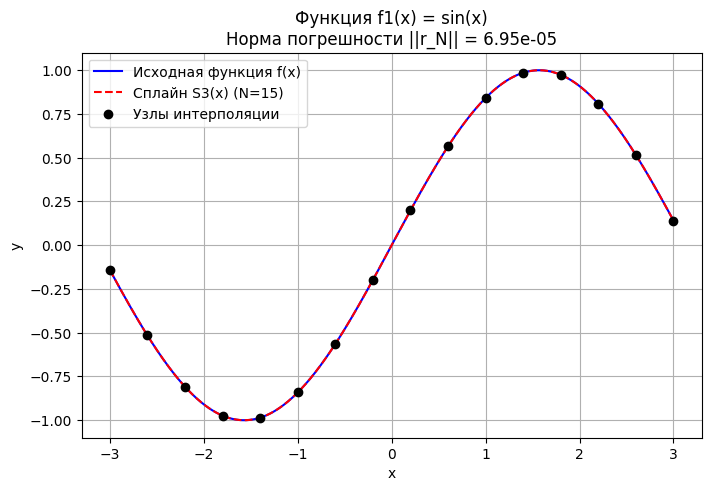

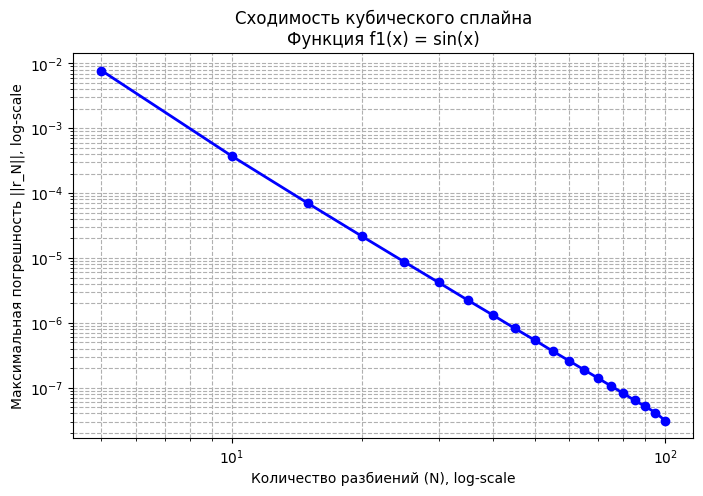


--- ЭКСПЕРИМЕНТ 2: f2(x) = sqrt(|x| + 4) ---


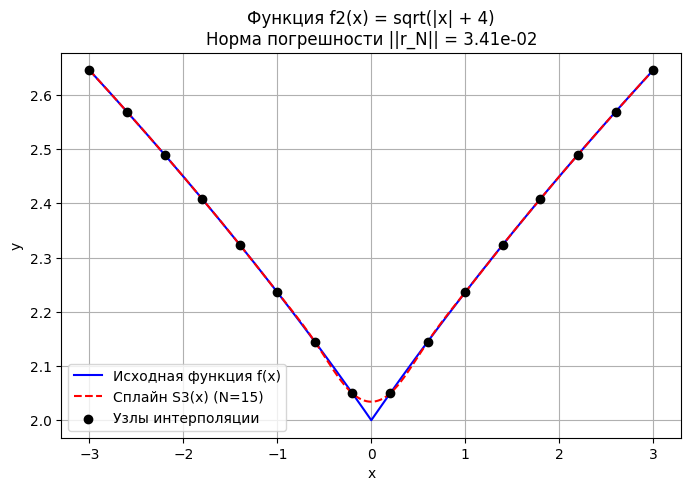

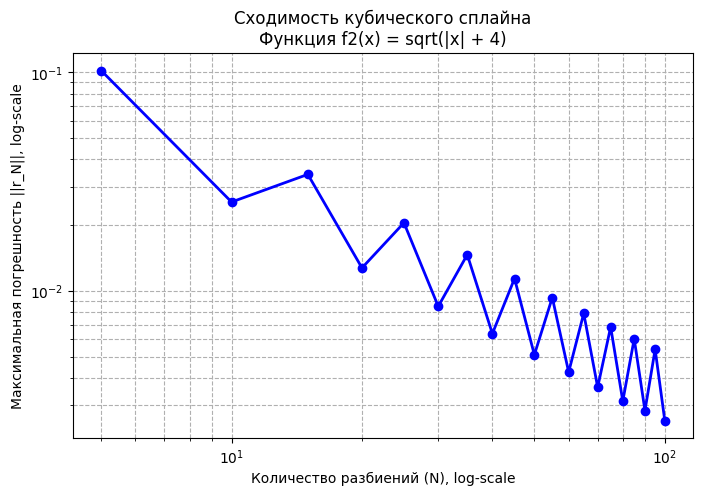

In [3]:
def run_experiment_1(func, dfunc, d2func, a, b, title):
    """
    Построение графика функции и сплайна при N=15.
    Вычисление нормы погрешности.
    """
    n_intervals = 15
    x_nodes = np.linspace(a, b, n_intervals + 1)
    y_nodes = func(x_nodes)
    
    dy_start = dfunc(a)
    d2y_end = d2func(b)
    
    spline = CubicSpline(x_nodes, y_nodes, dy_start, d2y_end)
    
    dense_x = np.linspace(a, b, 501)
    exact_y = func(dense_x)
    spline_y = spline.evaluate(dense_x)
    
    error_norm = np.max(np.abs(exact_y - spline_y))
    
    plt.figure(figsize=(8, 5))
    plt.plot(dense_x, exact_y, 'b-', label='Исходная функция f(x)')
    plt.plot(dense_x, spline_y, 'r--', label=f'Сплайн S3(x) (N={n_intervals})')
    plt.scatter(x_nodes, y_nodes, color='black', zorder=5, label='Узлы интерполяции')
    plt.title(f'{title}\nНорма погрешности ||r_N|| = {error_norm:.2e}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()
    plt.show()

def run_experiment_2(func, dfunc, d2func, a, b, title):
    """
    Построение графика сходимости сплайна (зависимость ошибки от N).
    Масштаб логарифмический по обеим осям.
    """
    n_values = np.arange(5, 105, 5)
    errors = []
    
    dense_x = np.linspace(a, b, 501)
    exact_y = func(dense_x)
    
    dy_start = dfunc(a)
    d2y_end = d2func(b)
    
    for n in n_values:
        x_nodes = np.linspace(a, b, n + 1)
        y_nodes = func(x_nodes)
        
        spline = CubicSpline(x_nodes, y_nodes, dy_start, d2y_end)
        spline_y = spline.evaluate(dense_x)
        
        error = np.max(np.abs(exact_y - spline_y))
        errors.append(error)
        
    plt.figure(figsize=(8, 5))
    plt.loglog(n_values, errors, 'bo-', linewidth=2)
    plt.title(f'Сходимость кубического сплайна\n{title}')
    plt.xlabel('Количество разбиений (N), log-scale')
    plt.ylabel('Максимальная погрешность ||r_N||, log-scale')
    plt.grid(True, which="both", ls="--")
    plt.show()

# Запуск экспериментов
a_interval, b_interval = -3.0, 3.0

print("--- ЭКСПЕРИМЕНТ 1: f1(x) = sin(x) ---")
run_experiment_1(f1, df1, d2f1, a_interval, b_interval, "Функция f1(x) = sin(x)")
run_experiment_2(f1, df1, d2f1, a_interval, b_interval, "Функция f1(x) = sin(x)")

print("\n--- ЭКСПЕРИМЕНТ 2: f2(x) = sqrt(|x| + 4) ---")
run_experiment_1(f2, df2, d2f2, a_interval, b_interval, "Функция f2(x) = sqrt(|x| + 4)")
run_experiment_2(f2, df2, d2f2, a_interval, b_interval, "Функция f2(x) = sqrt(|x| + 4)")

## Выводы о сходимости интерполяционного процесса

Анализ результатов вычислительного эксперимента позволяет сделать следующие выводы:

1. **Гладкая функция $f_1(x) = \sin(x)$:**
   Поскольку синус является аналитической (бесконечно дифференцируемой) функцией, интерполяционный кубический сплайн демонстрирует идеальную сходимость. На первом графике ($N=15$) кривые полностью совпадают. На логарифмическом графике сходимости отчетливо видна прямая линия, уходящая вниз. Прямая линия в координатах (log-log) подтверждает степенной характер убывания ошибки. Ошибка достигает предела машинной точности (около $10^{-15}$) примерно при $N=40$, после чего стабилизируется. Теоретическая оценка погрешности для сплайнов $O(h^4)$ подтверждается.

2. **Негладкая функция $f_2(x) = \sqrt{|x| + 4}$:**
   Данная функция имеет «особенность» в точке $x = 0$ — её первая производная терпит разрыв из-за наличия модуля. 
   В отличие от глобальных многочленов Ньютона (где на равномерной сетке в таком случае возникает фатальный феномен Рунге), кубический сплайн **сохраняет сходимость**. Это связано с тем, что сплайн строится локально (по кусочкам), и разрыв производной в одной точке не приводит к осцилляциям на всем отрезке.
   График сходимости показывает, что ошибка стабильно убывает при увеличении $N$, хотя скорость сходимости значительно ниже, чем у гладкой функции $f_1(x)$ (ошибка при $N=100$ достигает порядка $10^{-5}$).

**Общий вывод:** 
Использование кубических сплайнов является надежным и вычислительно устойчивым методом интерполяции. Сплайны успешно борются с феноменом Рунге на равномерных сетках и гарантируют сходимость даже для функций, имеющих особенности (изломы) в производных.